<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# Batch Orbit Determination — Complete Demo
---
*Scarabaeus OD Framework | Last revised 2026*

## What this notebook covers
This notebook is a **self-contained, verbose walkthrough** of **batch orbit determination (OD)**
using the Scarabaeus framework.  Every concept is explained in detail so that a reader unfamiliar
with the specific Scarabaeus API can follow along.

### Topics
| # | Topic |
|---|-------|
| 1 | Spacecraft model definition |
| 2 | Dynamics model catalogue — all available force models |
| 3 | Dynamics tuning — fidelity vs. cost trade-offs |
| 4 | True trajectory simulation |
| 5 | Measurement generation — Range, Range-Rate, Doppler, DOR, Angular, Centroiding |
| 6 | Reference (perturbed) trajectory |
| 7 | Batch filter — Least-Squares Batch (LSB) |
| 8 | Batch filter — SRIF Batch (SRIFB) + static parameter estimation (η_SRP) |
| 9 | Stochastic acceleration — Piecewise Gauss-Markov (PFOGM) batch OD |
| 10 | Measurement editing — chi-squared and date-range filters |
| 11 | Saving the OD solution |
| 12 | Solution analysis — covariance propagation, state extraction |

## How to run
Run cells top-to-bottom from the **project root** directory (`scarabaeus/`).
The first code cell will navigate there automatically if you opened the notebook from `tutorials/`.


## 0. Imports and Setup

We begin by importing Scarabaeus and the standard scientific stack, then establishing the working
directory, loading SPICE kernels, and defining the unit/frame system.

### Units
Scarabaeus uses a dimensional unit system.  `scb.Units.get_units()` returns unit objects that can
be composed with `*`, `/`, and `**` operators.  Every numerical quantity is wrapped in
`ArrayWUnits` so that unit consistency is enforced throughout the computation.

### Frames
Reference frames are managed via SPICE.  `J2000` is the standard inertial frame used for
heliocentric OD.

### SPICE kernels
The meta-kernel `locked_generic.tm` loads planet ephemerides (DE440), leap-seconds, planetary
constants, and Earth ground-station SPKs (DSS-14, DSS-63, etc.).


In [1]:
import os, sys
import numpy as np
import numpy.random as rnd
import matplotlib.pyplot as plt

import scarabaeus as scb

# ── working directory ────────────────────────────────────────────
# Notebooks live in tutorials/; data paths are relative to project root.
if os.path.basename(os.getcwd()) == 'tutorials':
    os.chdir('..')
print(f"Working directory : {os.getcwd()}")

# ── ensure output directories exist ─────────────────────────────
os.makedirs('data/measurements/radiometric', exist_ok=True)
os.makedirs('data/kernels/scenario',         exist_ok=True)

# ── units ────────────────────────────────────────────────────────
kg, km, sec = scb.Units.get_units(['kg', 'km', 'sec'])

# ── frames ───────────────────────────────────────────────────────
J2000, ITRF93, ECLIPJ2000, IAUEARTH = scb.Frame.generate_common_frames()
frame = J2000

# ── SPICE kernels ─────────────────────────────────────────────────
mk = os.path.join('data', 'kernels', 'locked', 'locked_generic.tm')
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(mk)
print("Kernels loaded.")


Working directory : /Users/zael5647/scarabaeus/docs/online_documentation/sphinx_files/_collections


SpiceNOSUCHFILE: 
================================================================================

Toolkit version: CSPICE_N0067

SPICE(NOSUCHFILE) --

The first file '../data/kernels/locked/ck/cas00084.tsc' specified by KERNELS_TO_LOAD in the file data/kernels/locked/locked_generic.tm could not be located.

furnsh_c --> FURNSH --> ZZLDKER

================================================================================

## Enhanced Plotting Helpers

The cells below add **calendar-date x-axis** versions of the plots above, plus new
visualization types: pre/post residual comparisons, state errors with ±3σ covariance
bounds, covariance evolution, and corner covariance plots.

Helper functions:
- `et2dt(et_arr)` — converts SPICE ET (seconds) to Python `datetime` objects
- `fmt_cal(ax)` — applies `AutoDateLocator + DateFormatter` for a clean calendar x-axis
- `add_hrs_axis(ax)` — adds a secondary top x-axis in hours from t0
- `resid_from_filter(flt, ds)` — extracts `(t_pre, r_pre, t_post, r_post)` arrays
- `corner_cov(P, labels)` — lower-triangle corner plot with RdBu_r correlation colouring


In [2]:
from datetime import datetime
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib import cm
from matplotlib.colors import Normalize

plt.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8,
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.35, 'grid.linestyle': '--',
})
CMAP = cm.tab10
COLORS = [CMAP(i / 10) for i in range(10)]

# reference epoch for the hours-from-t0 secondary axis
t0_et = None  # set after epoch_array is defined (run spacecraft/epoch setup cell first)


def et2dt(et_arr):
    """Convert SPICE ET seconds to list of datetime objects."""
    out = []
    for t in np.atleast_1d(et_arr):
        s = scb.SpiceManager.et2utc(float(t))
        try:
            parts = s.split()
            s2 = f"{parts[0]} {parts[1].capitalize()} {int(parts[2]):02d} {parts[3][:8]}"
            out.append(datetime.strptime(s2, "%Y %b %d %H:%M:%S"))
        except Exception:
            out.append(datetime(2021, 1, 1))
    return out


def fmt_cal(ax):
    """Apply calendar-date tick formatting to a matplotlib axis."""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=9))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))


def add_hrs_axis(ax, t0=None):
    """Add a secondary top x-axis showing hours from t0."""
    t0 = t0 if t0 is not None else t0_et
    from matplotlib.dates import date2num
    t0_num = date2num(et2dt([t0])[0])
    ax2 = ax.secondary_xaxis(
        "top",
        functions=(lambda x: (x - t0_num) * 24, lambda x: x / 24 + t0_num),
    )
    ax2.set_xlabel("Hours from t0 [TDB]", fontsize=8)
    ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f h"))
    return ax2


def resid_from_filter(flt_obj, ds_name):
    """Return (t_pre, r_pre, t_post, r_post) numpy arrays for a dataset name.

    Times are read from flt_obj.measurement_data (per-dataset t2 column).
    Residual values come from the [res, sigma] entries in pre/postfit_residuals.
    """
    pre  = flt_obj.prefit_residuals.get(ds_name, [])
    post = flt_obj.postfit_residuals.get(ds_name, [])
    # Retrieve t2 epochs for this dataset from the filter's measurement data
    t_ds = np.array([])
    for ds in flt_obj.measurement_data.datasets:
        if ds.set_name == ds_name:
            t_ds = np.array(ds.data["t2"])
            break
    t_pre  = t_ds[:len(pre)]  if len(pre)  else np.array([])
    r_pre  = np.array([d[0] for d in pre])  if pre  else np.array([])
    t_post = t_ds[:len(post)] if len(post) else np.array([])
    r_post = np.array([d[0] for d in post]) if post else np.array([])
    return t_pre, r_pre, t_post, r_post


def corner_cov(P, labels, title="Covariance Corner Plot", figsize=(9, 8)):
    """Lower-triangle corner plot.  Diagonal: 1-sigma.  Off-diagonal: correlation."""
    n    = P.shape[0]
    sig  = np.sqrt(np.diag(P))
    Corr = P / np.outer(sig, sig)
    fig, axes = plt.subplots(n, n, figsize=figsize)
    if n == 1:
        axes = np.array([[axes]])
    fig.suptitle(title, fontsize=11, fontweight="bold")
    cmap_r = cm.RdBu_r
    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            ax.set_xticks([]); ax.set_yticks([])
            if i == j:
                ax.set_facecolor("#dbeafe")
                ax.text(0.5, 0.62, f"1σ = {sig[i]:.2e}", ha="center", va="center",
                        transform=ax.transAxes, fontsize=6.5, fontweight="bold")
                ax.text(0.5, 0.32, labels[i], ha="center", va="center",
                        transform=ax.transAxes, fontsize=6.5, color="navy")
            elif i > j:
                c = float(Corr[i, j])
                ax.set_facecolor(cmap_r((c + 1) / 2))
                ax.text(0.5, 0.5, f"{c:+.2f}", ha="center", va="center",
                        transform=ax.transAxes, fontsize=7.5,
                        color="white" if abs(c) > 0.6 else "black")
            else:
                ax.set_visible(False)
    sm = cm.ScalarMappable(cmap=cmap_r, norm=Normalize(-1, 1)); sm.set_array([])
    fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.01, shrink=0.6, label="Correlation")
    plt.tight_layout()
    return fig


print("Plotting helpers ready.  (t0 will be set after epoch_array is defined)")


Plotting helpers ready.  (t0 will be set after epoch_array is defined)


## 1. Spacecraft Model

A `Spacecraft` object encodes the physical properties of the vehicle:

| Property | Description |
|----------|-------------|
| `name` | Human-readable label (also used as SPICE body name) |
| `spice_id` | NAIF integer ID (negative integers are spacecraft) |
| `tot_mass` | Total wet mass [kg] |
| `area` | Cross-sectional area for SRP [km²] |
| `ref_coeff` | Reflectivity coefficient C_r (dimensionless) |
| `n_plate_model` | Optional: N-plate SRP model for attitude-dependent SRP |

For the **"truth" simulation** we define `Orbiter` and for each **filter iteration** we create a
separate spacecraft object with a slightly different SPICE ID, so that SPICE kernel writes for the
reference trajectory do not clash.


In [3]:
# ── physical properties ──────────────────────────────────────────
dry_mass  = scb.ArrayWUnits(1500.0, kg)
fuel_mass = scb.ArrayWUnits(500.0,  kg)
area      = scb.ArrayWUnits(1e-6,   km**2)          # ~10 m²
cr        = scb.ArrayWUnits(1.5,    None)            # reflectivity (dimensionless)

# ── truth spacecraft ─────────────────────────────────────────────
Orbiter = scb.Spacecraft(
    name     = 'Orbiter_True',
    spice_id = -1000,
    tot_mass = dry_mass + fuel_mass,
    area     = area,
    ref_coeff= cr,
)

# ── gravitational origin ─────────────────────────────────────────
# Heliocentric orbit: Sun is the primary attracting body.
origin = scb.CelestialBody.from_constants('SUN')

# ── time window ──────────────────────────────────────────────────
# 3-day tracking arc with 30-min timesteps (good balance of coverage vs. cost)
time_0     = scb.SpiceManager.jd2et(2461809.72995654 + 1/3)  # start JD → ET
time_f     = scb.SpiceManager.jd2et(2461809.72995654 + 3)    # end   JD → ET
dt_step    = 30 * 60                                           # 30 minutes [s]
epoch_array = scb.EpochArray(np.arange(time_0, time_f, dt_step), time_frame='TDB')
epoch_0     = epoch_array[0]
print(f"Arc start : {scb.SpiceManager.et2utc(float(epoch_array[0]))} UTC")
print(f"Arc end   : {scb.SpiceManager.et2utc(float(epoch_array[-1]))} UTC")
print(f"N epochs  : {len(epoch_array)}")

# ── initial state (heliocentric J2000) ────────────────────────────
# Near-Earth heliocentric orbit (position ~1 AU from Sun)
pos_0 = scb.ArrayWFrame(
    np.array([-1.1123095885148e+08,  8.9094345479316e+07,  3.8656500948069e+07]), km, frame)
vel_0 = scb.ArrayWFrame(
    np.array([-20.6936999825159, -16.7800270812616, -6.6437327193572]), km/sec, frame)

print(f"\nInitial position magnitude : {np.linalg.norm(pos_0.values):.3e} km")
print(f"Initial velocity magnitude : {np.linalg.norm(vel_0.values):.6f} km/s")
t0_et = float(epoch_array[0])  # used by plotting helpers


SpiceMISSINGTIMEINFO: 
================================================================================

Toolkit version: CSPICE_N0067

SPICE(MISSINGTIMEINFO) --

The following variables, needed to convert between the input uniform time scales, were not found in the kernel pool: DELTET/DELTA_T_A, DELTET/K, DELTET/EB, DELTET/M. Your program may have failed to load a leapseconds kernel. Other possible causes of this problem include loading an invalid leapseconds kernel---one that lacks an initial \begindata marker or final newline character, or is otherwise corrupted---or deleting previously loaded kernel pool variables via calls to routines that clear the kernel pool.

unitim_c --> UNITIM

================================================================================

## 2. Dynamics Models Catalogue

Scarabaeus provides a **modular force model system** through `ForceModelTranslation`.
You turn on each perturbation with keyword flags.  This section documents every available option.

---

### 2.1 Point Mass Gravity (Keplerian)
The simplest model: the spacecraft is attracted only by the central body (Sun in our case).
No keyword needed — this is always included.

```python
fm = scb.ForceModelTranslation(primary_body=sc)
```

**When to use:** quick propagation checks, very short arcs, or when perturbations are negligible.

---

### 2.2 Third-Body Gravity
Gravitational pull from other solar-system bodies (planets, Moon, etc.).
Pass a list of SPICE body names.

```python
fm = scb.ForceModelTranslation(primary_body=sc,
                               third_bodies=['EARTH', 'JUPITER BARYCENTER', ...])
```

**Effect:** at 1 AU from the Sun, Earth and Jupiter perturbations are on the order of 10⁻⁶ km/s²
over a 3-day arc — significant for precision OD.

---

### 2.3 Cannonball Solar Radiation Pressure (SRP)
Isotropic SRP model.  Uses `area` and `ref_coeff` from the Spacecraft object.
The SRP scale factor η_SRP can be estimated as a static parameter in the OD state.

```python
fm = scb.ForceModelTranslation(primary_body=sc, cannonball_SRP=True)
```

**When to use:** missions without attitude data, or as a first-order SRP estimate.

---

### 2.4 N-Plate SRP
Attitude-dependent SRP computed face-by-face from a plate configuration file.
Requires a CK (attitude) kernel and an n-plate config JSON.

```python
fm = scb.ForceModelTranslation(primary_body=sc, nplate_SRP=True)
```

**When to use:** high-fidelity SRP for attitude-stabilised spacecraft with known CK.

---

### 2.5 Spherical Harmonics Gravity
Non-spherical gravity field (J2, J3, …) from a Stokes coefficients file.
Used for close-proximity or planetary orbits.

```python
fm = scb.ForceModelTranslation(
    primary_body     = sc,
    sph_harm         = True,
    sph_harm_order   = 8,                          # degree & order
    sph_harm_cs_file = 'data/dynamic_setup/sph_coefficients/Earth_100.json',
    sph_harm_body    = scb.EARTH,
    sph_harm_norm_flag = True,                     # normalized coefficients
)
```

**When to use:** Earth orbits, asteroid proximity operations.

---

### 2.6 Yarkovsky Effect
Thermal radiation recoil force — relevant for small bodies and asteroid proximity missions.

```python
# Included via separate YarkovskyEffect force-model object added to the propagator
```

---

### 2.7 First-Order Gauss-Markov (FOGM) Stochastic Acceleration
An exponentially correlated random acceleration — ideal for modelling uncharacterised
non-gravitational forces (outgassing, solar wind fluctuations, maneuver execution errors).

```python
fm = scb.ForceModelTranslation(
    primary_body           = sc,
    first_order_gauss_markov = True,
    fogm_beta              = np.array([1/3600, 1/3600, 1/3600]),  # [1/s] correlation = 1 hr
)
# State must include the FOGM acceleration as a *dynamic* parameter:
# .param('a_fogm', sc, a0_vec3, dynamics='dynamic')
```

---

### 2.8 Piecewise First-Order Gauss-Markov (PFOGM)
Like FOGM but the stochastic acceleration is constant within each batch interval.
Useful for batch OD where you want piece-wise constant unmodelled force estimation.

```python
batch_length = 6 * 3600   # 6-hour batches
n_batches    = int(np.ceil((time_f - time_0) / batch_length))

fm = scb.ForceModelTranslation(
    primary_body                  = sc,
    piecewise_first_order_gauss_markov = True,
    pfogm_batch_length            = batch_length,
    pfogm_n_batches               = n_batches,
    pfogm_beta                    = np.array([1/3600, 1/3600, 1/3600]),
    t0                            = epoch_array[0],
)
# State must include: .param('a_pfogm', sc, a0_vec_3n, dynamics='dynamic')
# where a0_vec_3n has 3 * n_batches elements.
```


## 3. Dynamics Tuning

**Dynamics tuning** means choosing which force models to include and verifying their fidelity
against an independent truth (SPICE ephemerides or higher-fidelity propagation).

### Workflow
1. Propagate with model A (low fidelity) and model B (high fidelity).
2. Compute the position difference over the arc.
3. If the difference exceeds your OD accuracy goal → model A is insufficient.
4. If the difference is negligible → model A is acceptable (and cheaper).

### Rules of thumb for a heliocentric 3-day arc at 1 AU
| Force | Magnitude [km/s²] | Position effect over 3 days |
|-------|-------------------|-----------------------------|
| Sun PM gravity | ~6×10⁻³ | dominant |
| Earth 3-body | ~6×10⁻⁷ | ~0.2 km |
| Jupiter 3-body | ~2×10⁻⁸ | ~0.01 km |
| Cannonball SRP | ~5×10⁻¹⁰ | ~0.001 km |

For sub-kilometre OD accuracy, Earth and Venus third-body gravity is **essential**.
SRP becomes important for light spacecraft over long arcs.

### Process noise tuning
When using sequential filters (next notebook), the process noise covariance **Q** must be tuned:
- Too large Q → filter accepts noise, inflated covariance.
- Too small Q → filter diverges when unmodelled forces accumulate.

A starting heuristic: set Q to (expected unmodelled acceleration)² × dt.


In [4]:
# ── compare Keplerian vs 3-body vs full model ────────────────────

third_bodies_all = ['MERCURY', 'VENUS', 'EARTH', 'MARS', 'JUPITER BARYCENTER']

def propagate_model(sc_body, pos, vel, epoch_arr, **fm_kwargs):
    state_def = scb.StateDefinition.from_components([
        ('position', 3, 'estimated', 'dynamic', sc_body, pos),
        ('velocity', 3, 'estimated', 'dynamic', sc_body, vel),
    ])
    sv = scb.StateArray(epoch=epoch_arr[0], origin=origin, state=state_def)
    fm = scb.ForceModelTranslation(primary_body=sc_body, **fm_kwargs)
    prop = scb.Propagator(primary_body=sc_body, state_vector=sv,
                          tspan=epoch_arr, force_models=fm)
    prop.propagate()
    pos_arr = prop.propagated_state_array.values_array[('position', sc_body.spice_id)][0]
    return pos_arr   # shape (N, 3)

# Use a shorter window for tuning comparison (faster)
tune_end    = scb.SpiceManager.jd2et(2461809.72995654 + 1/3 + 1)  # 1-day arc
epoch_tune  = scb.EpochArray(np.arange(time_0, tune_end, dt_step), time_frame='TDB')

# Keplerian helper SC (unique SPICE ID to avoid conflicts)
sc_kep  = scb.Spacecraft('tune_kep',  -1090, dry_mass+fuel_mass, area, cr)
sc_3b   = scb.Spacecraft('tune_3b',   -1091, dry_mass+fuel_mass, area, cr)
sc_full = scb.Spacecraft('tune_full', -1092, dry_mass+fuel_mass, area, cr)

print("Propagating Keplerian ...")
pos_kep  = propagate_model(sc_kep,  pos_0, vel_0, epoch_tune)
print("Propagating 3-body ...")
pos_3b   = propagate_model(sc_3b,   pos_0, vel_0, epoch_tune,
                            third_bodies=['EARTH', 'VENUS'])
print("Propagating 3-body + cannonball SRP ...")
pos_full = propagate_model(sc_full, pos_0, vel_0, epoch_tune,
                            third_bodies=['EARTH', 'VENUS'], cannonball_SRP=True)

t_hr = (epoch_tune.times.values - epoch_tune.times.values[0]) / 3600

err_3b   = np.linalg.norm(pos_3b   - pos_kep,  axis=1)   # 3-body vs Keplerian
err_full = np.linalg.norm(pos_full - pos_3b,   axis=1)   # SRP effect on top of 3-body

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].semilogy(t_hr, err_3b,   'b-', lw=1.5, label='3-body − Keplerian')
axes[0].set_ylabel('Position diff [km]')
axes[0].set_title('Dynamics Tuning: effect of each force model (1-day arc)')
axes[0].legend(); axes[0].grid(True, alpha=0.4)
axes[1].semilogy(t_hr, err_full, 'r-', lw=1.5, label='(3-body+SRP) − 3-body')
axes[1].set_ylabel('Position diff [km]')
axes[1].set_xlabel('Time [hr]')
axes[1].legend(); axes[1].grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(f"\nMax position difference (3-body vs Keplerian)  : {err_3b.max():.4f} km")
print(f"Max position difference (SRP effect on 3-body) : {err_full.max():.6f} km")


SpiceMISSINGTIMEINFO: 
================================================================================

Toolkit version: CSPICE_N0067

SPICE(MISSINGTIMEINFO) --

The following variables, needed to convert between the input uniform time scales, were not found in the kernel pool: DELTET/DELTA_T_A, DELTET/K, DELTET/EB, DELTET/M. Your program may have failed to load a leapseconds kernel. Other possible causes of this problem include loading an invalid leapseconds kernel---one that lacks an initial \begindata marker or final newline character, or is otherwise corrupted---or deleting previously loaded kernel pool variables via calls to routines that clear the kernel pool.

unitim_c --> UNITIM

================================================================================

#### Enhanced: Dynamics Tuning — Calendar-Date X-Axis

The same data as the plot above, now with UTC calendar date as the primary x-axis
and hours from t0 as a secondary (top) axis.  This layout is the standard for all
enhanced plots in this notebook.


In [5]:
dts_tune = et2dt(epoch_tune.times.values)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
fig.suptitle("Dynamics Tuning — Position Differences (calendar date)",
             fontsize=12, fontweight="bold")

axes[0].semilogy(dts_tune, err_3b,   lw=1.8, color=COLORS[0], label="3-body − Keplerian")
axes[0].set_ylabel("Position diff [km]"); axes[0].legend()
add_hrs_axis(axes[0], t0_et); fmt_cal(axes[0])

axes[1].semilogy(dts_tune, err_full, lw=1.8, color=COLORS[1], label="(3-body+SRP) − 3-body")
axes[1].set_ylabel("Position diff [km]"); axes[1].set_xlabel("Calendar Date [UTC]")
axes[1].legend(); fmt_cal(axes[1])

plt.tight_layout(); plt.show()


NameError: name 'epoch_tune' is not defined

## 4. True Trajectory Generation

We propagate the **true trajectory** using the highest-fidelity force model available.
This trajectory is saved as a SPICE SPK kernel so it can be queried later for ground truth
comparisons and measurement generation.

The `Trajectory` object wraps the propagated state array and provides:
- `write_to_spk(path)` — write binary SPK kernel
- `start_epoch`, `end_epoch` — arc boundaries

In real operations the "truth" is unknown; here we simulate it to validate the OD solution.


In [6]:
# ── force model for truth propagation ────────────────────────────
# Use 3-body gravity + cannonball SRP as the "truth" dynamics.
# The OD filter will use the same model (ideal case) — in Section 8 we perturb η_SRP.
fm_truth = scb.ForceModelTranslation(
    primary_body  = Orbiter,
    third_bodies  = ['MERCURY', 'VENUS', 'EARTH'],
    cannonball_SRP= True,
)

state_0_truth = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', Orbiter, pos_0),
    ('velocity', 3, 'estimated', 'dynamic', Orbiter, vel_0),
])
sv_truth = scb.StateArray(epoch=epoch_0, origin=origin, state=state_0_truth)

prop_truth = scb.Propagator(
    primary_body = Orbiter,
    state_vector = sv_truth,
    tspan        = epoch_array,
    force_models = fm_truth,
)
print("Propagating true trajectory ...")
prop_truth.propagate()
state_prop_truth = prop_truth.propagated_state_array

# ── save as SPICE SPK ─────────────────────────────────────────────
true_spk = 'data/kernels/scenario/batch_orbiter_true.bsp'
if os.path.isfile(true_spk):
    os.remove(true_spk)
orbiter_traj_true = scb.Trajectory(state_array=state_prop_truth)
orbiter_traj_true.write_to_spk(true_spk)
print(f"True trajectory saved to: {true_spk}")


NameError: name 'pos_0' is not defined

## 5. Measurement Generation

Scarabaeus models all standard radiometric and optical navigation measurement types.
This section shows how to set up each model, simulate noisy observations on the true
trajectory, save them to JSON files, and reload them for OD use.

### Measurement generation workflow
```
Spacecraft trajectory (true SPK)
        │
        ▼
write_observed_measurements(target, epoch_array, noisy=True, file_name=stem)
        │   adds Gaussian noise with the specified sigma
        ▼
JSON file in data/measurements/radiometric/
        │
        ▼
observed_measurements(file_name, meas_name, units) → (epoch_array, times_sec, values)
```

### Available measurement types
| Class | Observable | Typical sigma |
|-------|-----------|---------------|
| `RangeIdeal` | Two-way range [km] | 1 m (1e-3 km) |
| `RangeRateIdeal` | Two-way range-rate [km/s] | 0.1 mm/s (1e-4 km/s) |
| `DopplerIdeal` | Doppler frequency shift [Hz] | ~1 Hz |
| `DiffOneWayRangeIdeal` | ΔDOR [s] | ~1 ns |
| `AngularIdeal` | RA/DEC [rad] | ~10 μrad |
| `CentroidingIdeal` | Pixel centroid [pixel] | 0.5–2 pixel |
| `SequentialRangingReal` | Sequential ranging (RU) | see DSN calibration |
| `DopplerReal` | Doppler (DSN processing) | see DSN calibration |


In [7]:
# ─────────────────────────────────────────────────────────────────
# 5.1  Ground-station sensors
# ─────────────────────────────────────────────────────────────────
# GroundStation wraps a SPICE-body ground station.
# DSS-14 (Goldstone, CA) and DSS-63 (Madrid) are built into the generic kernel.
GS1 = scb.GroundStation('DSS-14')
GS2 = scb.GroundStation('DSS-63')

# ─────────────────────────────────────────────────────────────────
# 5.2  Measurement noise levels
# ─────────────────────────────────────────────────────────────────
range_sigma     = scb.ArrayWUnits(1e-3,  km)           # 1 m two-way range
rangerate_sigma = scb.ArrayWUnits(1e-5,  km/sec)       # 0.01 mm/s range-rate
doppler_sigma   = scb.ArrayWUnits(1e-3,  sec**-1)      # 1 mHz Doppler

# ─────────────────────────────────────────────────────────────────
# 5.3  Instantiate all measurement models
# ─────────────────────────────────────────────────────────────────

# ── Radiometric: Range ───────────────────────────────────────────
Range_GS1     = scb.RangeIdeal('GS1 Range',     GS1,  sigma=range_sigma)
Range_GS2     = scb.RangeIdeal('GS2 Range',     GS2,  sigma=range_sigma)

# ── Radiometric: Range-Rate ──────────────────────────────────────
RangeRate_GS1 = scb.RangeRateIdeal('GS1 RangeRate', GS1, sigma=rangerate_sigma)
RangeRate_GS2 = scb.RangeRateIdeal('GS2 RangeRate', GS2, sigma=rangerate_sigma)

# ── Radiometric: Doppler (requires Antenna instrument on SC) ─────
antenna_sc = scb.Antenna('SC_Antenna', spice_id=Orbiter.spice_id)
Orbiter.add_instrument([antenna_sc])
tx_freq = scb.ArrayWUnits(8.4e9, sec**-1)   # X-band uplink [Hz]
Doppler_GS1 = scb.DopplerIdeal(
    name                    = 'GS1 Doppler 2W',
    instrument              = GS1,
    sigma                   = doppler_sigma,
    antenna_name            = antenna_sc.name,
    doppler_transmit_frequency = tx_freq,
)
# 3-way Doppler (uplink GS1, downlink GS2)
Doppler_GS1GS2 = scb.DopplerIdeal(
    name                    = 'GS1-GS2 Doppler 3W',
    instrument              = GS1,
    sigma                   = doppler_sigma,
    antenna_name            = antenna_sc.name,
    doppler_transmit_frequency = tx_freq,
    ground_station_2        = GS2,
)

# ── Differential One-Way Range (ΔDOR) ────────────────────────────
dor_sigma = scb.ArrayWUnits(1e-9, sec)   # ~1 ns timing precision
DOR_GS1GS2 = scb.DiffOneWayRangeIdeal(
    name           = 'GS1-GS2 DDOR',
    instrument     = GS1,
    sigma          = dor_sigma,
    ground_station_2 = GS2,
)

print("All measurement models instantiated.")
print(f"  Range_GS1     : {Range_GS1.name}")
print(f"  RangeRate_GS1 : {RangeRate_GS1.name}")
print(f"  Doppler_GS1   : {Doppler_GS1.name}")
print(f"  Doppler 3W    : {Doppler_GS1GS2.name}")
print(f"  DDOR          : {DOR_GS1GS2.name}")


All measurement models instantiated.
  Range_GS1     : GS1 Range
  RangeRate_GS1 : GS1 RangeRate
  Doppler_GS1   : GS1 Doppler 2W
  Doppler 3W    : GS1-GS2 Doppler 3W
  DDOR          : GS1-GS2 DDOR


In [8]:
# ─────────────────────────────────────────────────────────────────
# 5.4  Generate and save observed (noisy) measurements
# ─────────────────────────────────────────────────────────────────
# write_observed_measurements:
#   target=Orbiter   → query this body's SPK for geometry
#   epoch_array      → timestamps at which to compute
#   noisy=True       → add Gaussian noise with the model's sigma
#   file_name="stem" → write to data/measurements/radiometric/<stem>.json

for model, stem in [
    (Range_GS1,      'batch_range_GS1'),
    (RangeRate_GS1,  'batch_rangerate_GS1'),
    (Range_GS2,      'batch_range_GS2'),
    (RangeRate_GS2,  'batch_rangerate_GS2'),
    (Doppler_GS1,    'batch_doppler_GS1'),
    (Doppler_GS1GS2, 'batch_doppler_3W'),
    (DOR_GS1GS2,     'batch_ddor'),
]:
    model.write_observed_measurements(
        target      = Orbiter,
        epoch_array = epoch_array,
        noisy       = True,
        file_name   = stem,
    )
    print(f"Written: {stem}.json")

# ─────────────────────────────────────────────────────────────────
# 5.5  Load back the primary measurements (GS1 Range + RangeRate)
# ─────────────────────────────────────────────────────────────────
obs_range_GS1 = Range_GS1.observed_measurements(
    file_name = 'data/measurements/radiometric/batch_range_GS1.json',
    meas_name = 'meas_ideal',
    units     = km,
)
obs_rr_GS1 = RangeRate_GS1.observed_measurements(
    file_name = 'data/measurements/radiometric/batch_rangerate_GS1.json',
    meas_name = 'meas_ideal',
    units     = km/sec,
)
obs_range_GS2 = Range_GS2.observed_measurements(
    file_name = 'data/measurements/radiometric/batch_range_GS2.json',
    meas_name = 'meas_ideal',
    units     = km,
)
obs_rr_GS2 = RangeRate_GS2.observed_measurements(
    file_name = 'data/measurements/radiometric/batch_rangerate_GS2.json',
    meas_name = 'meas_ideal',
    units     = km/sec,
)

# Tuple layout: (epoch_array, times_sec, values_array)
print(f"\nGS1 Range   — {len(obs_range_GS1[2])} measurements")
print(f"GS1 RangeRate — {len(obs_rr_GS1[2])} measurements")
print(f"GS2 Range   — {len(obs_range_GS2[2])} measurements")
print(f"GS2 RangeRate — {len(obs_rr_GS2[2])} measurements")


NameError: name 'epoch_array' is not defined

In [9]:
# ─────────────────────────────────────────────────────────────────
# 5.6  Plot the simulated measurements
# ─────────────────────────────────────────────────────────────────
t_hrs_range = (obs_range_GS1[1] - obs_range_GS1[1][0]) / 3600

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Range GS1
axes[0,0].plot(t_hrs_range, obs_range_GS1[2], '.', ms=2, label='GS1')
axes[0,0].set_title('Two-Way Range [km]'); axes[0,0].set_ylabel('Range [km]')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Range GS2
t_hrs_range2 = (obs_range_GS2[1] - obs_range_GS2[1][0]) / 3600
axes[0,1].plot(t_hrs_range2, obs_range_GS2[2], '.', ms=2, color='orange', label='GS2')
axes[0,1].set_title('Two-Way Range [km] — GS2'); axes[0,1].set_ylabel('Range [km]')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# RangeRate GS1
t_hrs_rr = (obs_rr_GS1[1] - obs_rr_GS1[1][0]) / 3600
axes[1,0].plot(t_hrs_rr, obs_rr_GS1[2] * 1e3, '.', ms=2, label='GS1')
axes[1,0].set_title('Range-Rate [m/s]'); axes[1,0].set_ylabel('Range-rate [m/s]')
axes[1,0].set_xlabel('Time [hr]'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# RangeRate GS2
t_hrs_rr2 = (obs_rr_GS2[1] - obs_rr_GS2[1][0]) / 3600
axes[1,1].plot(t_hrs_rr2, obs_rr_GS2[2] * 1e3, '.', ms=2, color='orange', label='GS2')
axes[1,1].set_title('Range-Rate [m/s] — GS2'); axes[1,1].set_ylabel('Range-rate [m/s]')
axes[1,1].set_xlabel('Time [hr]'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Simulated Measurements — Batch OD Demo', fontweight='bold')
plt.tight_layout()
plt.show()


NameError: name 'obs_range_GS1' is not defined

#### Enhanced: Measurement Gallery — Calendar-Date X-Axis


NameError: name 'obs_range_GS1' is not defined

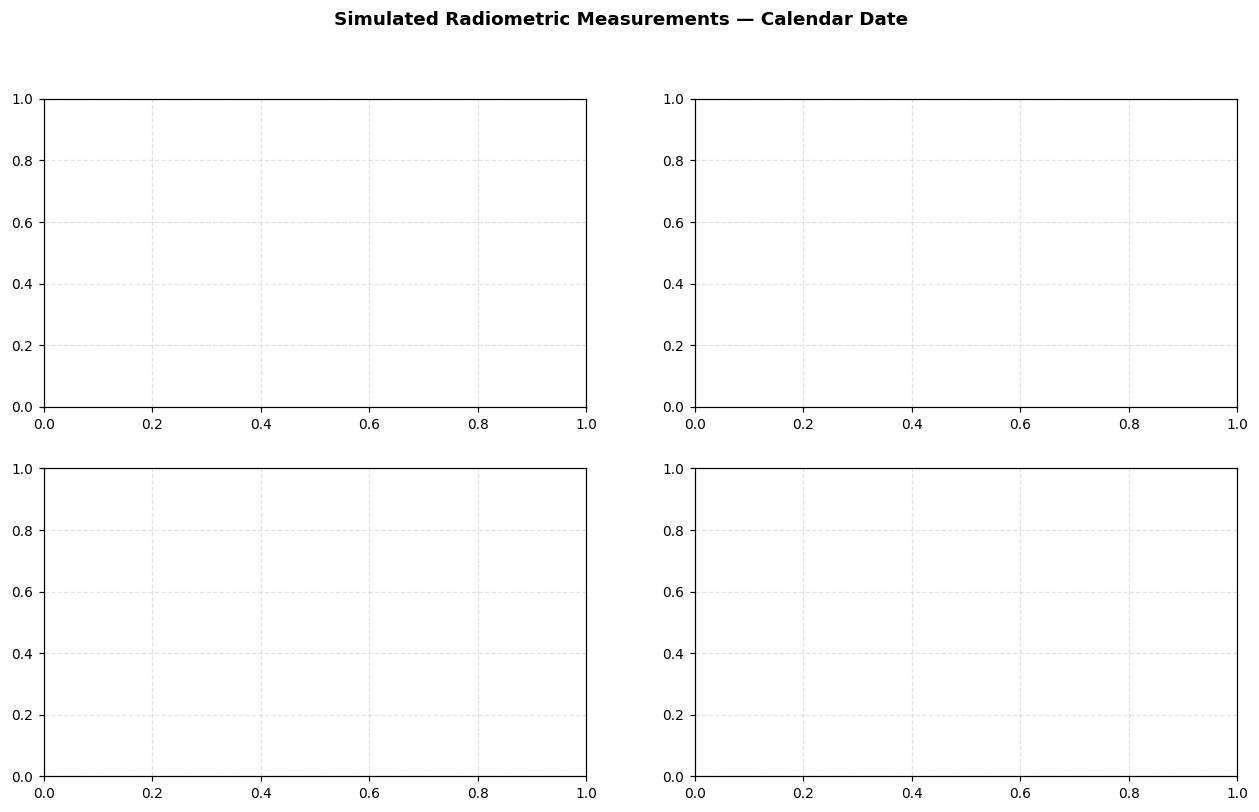

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Simulated Radiometric Measurements — Calendar Date",
             fontsize=12, fontweight="bold")

for ax, obs, lbl, yscale, col in [
    (axes[0, 0], obs_range_GS1, "GS1 Range [km]",      1.0,  COLORS[0]),
    (axes[0, 1], obs_range_GS2, "GS2 Range [km]",      1.0,  COLORS[1]),
    (axes[1, 0], obs_rr_GS1,   "GS1 Range-Rate [m/s]", 1e3,  COLORS[2]),
    (axes[1, 1], obs_rr_GS2,   "GS2 Range-Rate [m/s]", 1e3,  COLORS[3]),
]:
    dts = et2dt(obs[1])
    ax.plot(dts, obs[2] * yscale, ".", ms=2.5, color=col, alpha=0.7)
    ax.set_ylabel(lbl); fmt_cal(ax); add_hrs_axis(ax, t0_et)

axes[1, 0].set_xlabel("Calendar Date [UTC]")
axes[1, 1].set_xlabel("Calendar Date [UTC]")
plt.tight_layout(); plt.show()


## 6. Reference Trajectory (Perturbed Initial Conditions)

In real OD we do not know the true initial state; we start from a **reference trajectory**
obtained from a previous solution or orbit determination arc, then apply the filter to correct it.

Here we simulate this by **perturbing** the true initial state:
- Position: ±1 km error (typical for deep-space missions after several days without tracking)
- Velocity: ±1 mm/s error

The filter's job is to recover the deviation `δx = x_true − x_ref` at each measurement epoch.

Each filter iteration uses a **new Spacecraft object** (unique SPICE ID) so that its SPK kernel
does not overwrite the truth or previous iteration's kernel.

### Covariance initialisation
The **initial covariance matrix P₀** encodes our uncertainty in the reference initial state.
Rule of thumb: set the 1-σ values to roughly the size of the perturbation.


In [11]:
# ── perturb initial state ─────────────────────────────────────────
delta_pos_km  = np.array([1.0, 1.0, 1.0])       # 1 km position error in each axis
delta_vel_kms = np.array([1e-3, 1e-3, 1e-3])    # 1 mm/s velocity error in each axis

delta_pos = scb.ArrayWUnits(delta_pos_km,  km)
delta_vel = scb.ArrayWUnits(delta_vel_kms, km/sec)

pos_ref = scb.ArrayWFrame(pos_0.quantity + delta_pos, frame)
vel_ref = scb.ArrayWFrame(vel_0.quantity + delta_vel, frame)

# ── reference spacecraft (iteration 1) ───────────────────────────
Orbiter_ref = scb.Spacecraft('Orbiter_Ref_it1', -1001,
                              dry_mass+fuel_mass, area, cr)

state_ref = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', Orbiter_ref, pos_ref),
    ('velocity', 3, 'estimated', 'dynamic', Orbiter_ref, vel_ref),
])
sv_ref = scb.StateArray(epoch=epoch_0, origin=origin, state=state_ref)

# ── propagate reference with same force model as truth ───────────
fm_ref = scb.ForceModelTranslation(
    primary_body   = Orbiter_ref,
    third_bodies   = ['MERCURY', 'VENUS', 'EARTH'],
    cannonball_SRP = True,
)
prop_ref = scb.Propagator(
    primary_body = Orbiter_ref,
    state_vector = sv_ref,
    tspan        = epoch_array,
    force_models = fm_ref,
)

# ── initial covariance P₀ ────────────────────────────────────────
# Set 1-σ to ~3× the perturbation (conservative initialisation)
pos_sig = scb.ArrayWUnits(3 * delta_pos_km[0], km)
vel_sig = scb.ArrayWUnits(3 * delta_vel_kms[0], km/sec)
state_cov = scb.CovarianceMatrix(
    [pos_sig, pos_sig, pos_sig, vel_sig, vel_sig, vel_sig],
    epoch_array[1],
    from_list=True,
)
print("Reference trajectory and P₀ ready.")
print(f"  Position 1-σ : {3*delta_pos_km[0]:.1f} km")
print(f"  Velocity 1-σ : {3*delta_vel_kms[0]:.4f} km/s")


NameError: name 'pos_0' is not defined

## 7. Batch Filter: Least-Squares Batch (LSB)

### Theory
The Least-Squares Batch (LSB) filter solves the normal equations

$$\mathbf{x}^* = \left(\mathbf{H}^T \mathbf{W} \mathbf{H} + \mathbf{P}_0^{-1}\right)^{-1}
  \mathbf{H}^T \mathbf{W} \mathbf{y}$$

where **H** is the measurement sensitivity matrix, **W = R⁻¹** is the measurement weight matrix,
**y** are the pre-fit residuals, and **P₀** is the initial state covariance (acts as a Tikhonov
regulariser).

The solution is iterated: after each batch solve the reference trajectory is updated and the
process repeats until `‖δx‖ < convergence_threshold`.

### Measurement specification
`MeasurementSpec.many()` or `MeasurementSpec.from_dict()` combine multiple measurement datasets
into the single structure the filter expects.

### FilterSettings
`FilterSettings` gathers all configuration:
- `initial_covariance` — P₀
- `process_noise` — `ProcessNoiseSettings` (batch filters: usually not used; sequential: SNC/DMC)
- `output` — `OutputSettings` for controlling what is saved


In [12]:
# ── measurement list ────────────────────────────────────────────
meas_list_lsb = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=Range_GS1,     observed_meas=obs_range_GS1,
                        dataset_name='GS1 Range'),
    scb.MeasurementSpec(model=RangeRate_GS1, observed_meas=obs_rr_GS1,
                        dataset_name='GS1 RangeRate'),
    scb.MeasurementSpec(model=Range_GS2,     observed_meas=obs_range_GS2,
                        dataset_name='GS2 Range'),
    scb.MeasurementSpec(model=RangeRate_GS2, observed_meas=obs_rr_GS2,
                        dataset_name='GS2 RangeRate'),
)

# ── filter settings ──────────────────────────────────────────────
settings_lsb = scb.FilterSettings(
    initial_covariance = state_cov,
    output = scb.OutputSettings(
        metadata = {'version': '1.0', 'filter': 'LSB', 'arc': '3-day'},
    ),
)

# ── instantiate LSB filter ───────────────────────────────────────
# LSB = Least-Squares Batch.
# traj_name: SPK filename for the reference trajectory of this iteration.
ref_spk_lsb = 'data/kernels/scenario/batch_orbiter_ref_lsb.bsp'
if os.path.isfile(ref_spk_lsb): os.remove(ref_spk_lsb)

lsb = scb.LSB(
    propagator   = prop_ref,
    settings     = settings_lsb,
    measurements = meas_list_lsb,
    traj_name    = 'batch_orbiter_ref_lsb.bsp',
)

# ── run the batch solver ─────────────────────────────────────────
print("Running LSB batch filter ...")
solution_lsb, n_iters_lsb, converged_lsb = lsb.fit(
    max_iterations       = 10,
    convergence_threshold= 1e-6,
    verbose              = True,
    traj_name            = 'batch_orbiter_ref.bsp',
)
print(f"\nConverged: {converged_lsb}  after {n_iters_lsb} iteration(s)")


NameError: name 'obs_range_GS1' is not defined

In [13]:
# ── plot results: state errors and post-fit residuals ────────────
scb.Plotting.get_fig_handle(
    scb.Plotting.plot_state_errors(
        solution_lsb, orbiter_traj_true, epoch_array, 3,
        title='LSB — State Errors vs Truth'
    )
)
scb.Plotting.get_fig_handle(
    scb.Plotting.plot_postfits_scatter(
        solution_lsb, epoch_array,
        lsb.measurement_data.dataset_names, 3
    )
)
plt.show()

# ── extract estimated state at epoch_0 ───────────────────────────
final_dev = solution_lsb.map_state_deviation_to_epoch()
print("\nEstimated state deviation at epoch_0:")
print(f"  Δpos [km]   : {final_dev[:3]}")
print(f"  Δvel [km/s] : {final_dev[3:6]}")


NameError: name 'solution_lsb' is not defined

#### Enhanced: LSB — Pre-fit vs Post-fit Residuals (Calendar Date)

Side-by-side scatter for each dataset.  The red dashed lines are ±3σ measurement noise.
A well-converged filter should have post-fit residuals uniformly distributed inside the
±3σ band with no systematic trends.


NameError: name 'lsb' is not defined

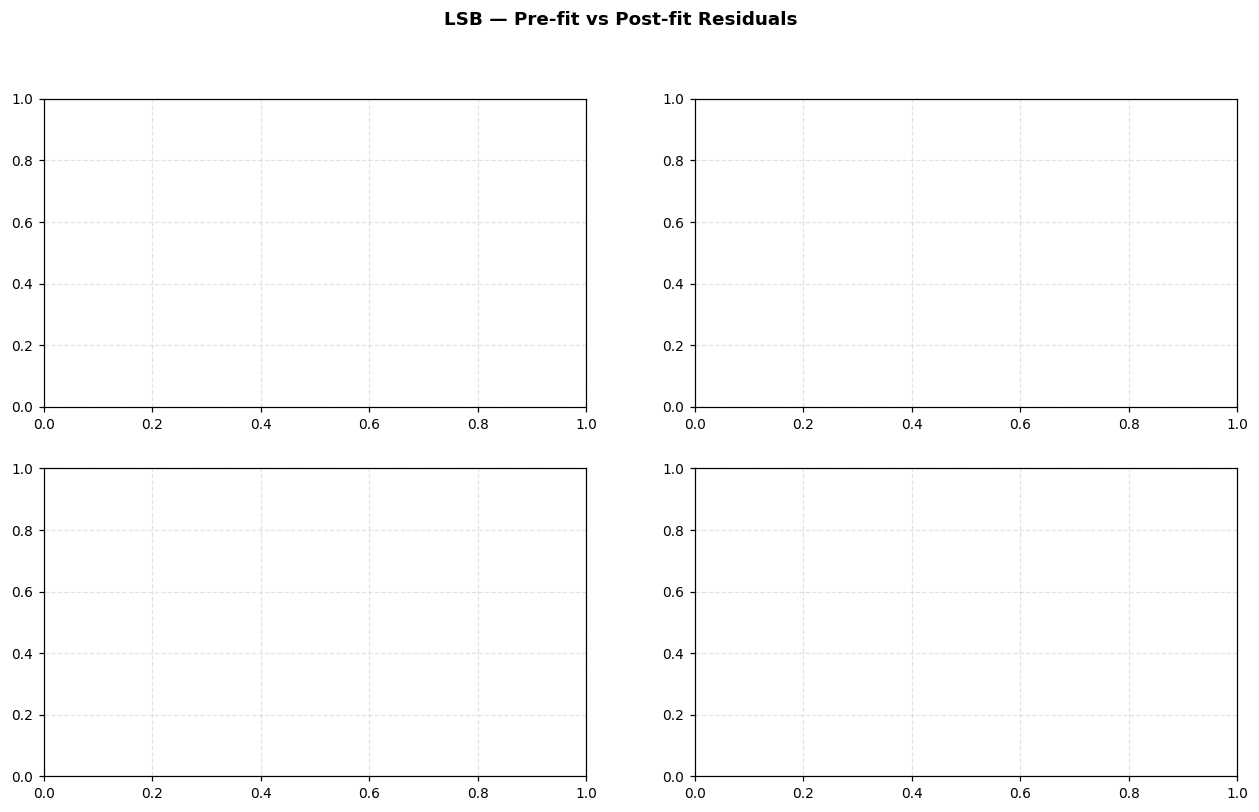

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("LSB — Pre-fit vs Post-fit Residuals", fontsize=12, fontweight="bold")

for row, (ds_name, sigma_val, ylabel) in enumerate([
    ("GS1 Range",     float(range_sigma.values) * 1e3,     "Range residual [m]"),
    ("GS1 RangeRate", float(rangerate_sigma.values) * 1e6, "RangeRate residual [mm/s]"),
]):
    scale = 1e3 if row == 0 else 1e6
    t_pre, r_pre, t_post, r_post = resid_from_filter(lsb, ds_name)
    for col, (t_r, r_r, label) in enumerate(
        [(t_pre, r_pre, "Pre-fit"), (t_post, r_post, "Post-fit")]
    ):
        ax = axes[row, col]
        if len(t_r):
            ax.plot(et2dt(t_r), r_r * scale, ".", ms=3,
                    color=COLORS[row * 2 + col], alpha=0.7, label=label)
            ax.axhline(0, color="k", lw=0.6, ls="--")
            ax.axhline( 3 * sigma_val, color="r", lw=0.9, ls="--", alpha=0.7, label="±3σ")
            ax.axhline(-3 * sigma_val, color="r", lw=0.9, ls="--", alpha=0.7)
        ax.set_title(f"{ds_name} — {label}")
        ax.set_ylabel(ylabel); ax.set_xlabel("Calendar Date [UTC]")
        fmt_cal(ax); ax.legend()

plt.tight_layout(); plt.show()


#### Enhanced: LSB — Observed vs Computed + Post-fit Residuals (GS1 Range)

Two-panel plot:
- **Top**: observed (dots) and computed (line) range overlaid — shows how well the
  estimated trajectory reproduces the data.
- **Bottom**: post-fit residual = observed − computed.  Should be zero-mean Gaussian
  noise at the ±3σ measurement level.


In [15]:
t_pre_r, r_pre_r, t_post_r, r_post_r = resid_from_filter(lsb, "GS1 Range")
if len(t_post_r) > 0:
    obs_at_post  = np.interp(t_post_r, obs_range_GS1[1], obs_range_GS1[2])
    comp_at_post = obs_at_post - r_post_r          # computed = obs − residual
    dts_post     = et2dt(t_post_r)
    sigma_m      = float(range_sigma.values) * 1e3  # sigma in metres

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [2, 1]})
    fig.suptitle("LSB — GS1 Range: Observed vs Computed", fontsize=12, fontweight="bold")

    ax1.plot(dts_post, obs_at_post  * 1e3, ".", ms=3, color=COLORS[0], alpha=0.7, label="Observed")
    ax1.plot(dts_post, comp_at_post * 1e3, "-", lw=1.2, color=COLORS[1], alpha=0.9, label="Computed")
    ax1.set_ylabel("Range [m]"); ax1.legend(); fmt_cal(ax1); add_hrs_axis(ax1, t0_et)

    ax2.plot(dts_post, r_post_r * 1e3, ".", ms=3, color=COLORS[2], alpha=0.8, label="Post-fit resid.")
    ax2.axhline(0, color="k", lw=0.6, ls="--")
    ax2.axhline( 3 * sigma_m, color="r", lw=0.9, ls="--", alpha=0.7, label="±3σ")
    ax2.axhline(-3 * sigma_m, color="r", lw=0.9, ls="--", alpha=0.7)
    ax2.set_ylabel("Residual [m]"); ax2.set_xlabel("Calendar Date [UTC]")
    ax2.legend(); fmt_cal(ax2)

    plt.tight_layout(); plt.show()
else:
    print("No post-fit residuals available — run the LSB filter cell first.")


NameError: name 'lsb' is not defined

#### Enhanced: LSB — State Errors with ±3σ Covariance Bounds

6-panel grid showing position errors (top row, km) and velocity errors (bottom row, m/s)
vs the true trajectory, with ±3σ covariance shading from `solution.propagate_covariance()`.

A well-performing estimator should have the error consistently *inside* the ±3σ band.
The band shrinking over time reflects the accumulation of measurements.


In [16]:
et_meas  = solution_lsb.timestamps
meas_ep  = scb.EpochArray(scb.ArrayWUnits(et_meas, sec), "TDB")
est_pos  = solution_lsb.state_est[:, :3]
est_vel  = solution_lsb.state_est[:, 3:6]

# Interpolate truth to measurement epochs
truth_t   = epoch_array.times.values
truth_pos = state_prop_truth.values_array[("position", Orbiter.spice_id)][0]  # (N,3) km
truth_vel = state_prop_truth.values_array[("velocity", Orbiter.spice_id)][0]  # (N,3) km/s
tp_meas   = np.column_stack([np.interp(et_meas, truth_t, truth_pos[:, j]) for j in range(3)])
tv_meas   = np.column_stack([np.interp(et_meas, truth_t, truth_vel[:, j]) for j in range(3)])

err_pos = est_pos - tp_meas
err_vel = est_vel - tv_meas

# Covariance at measurement epochs
P_list  = solution_lsb.propagate_covariance(meas_ep)
sig_pos = np.array([np.sqrt(np.diag(P)[:3]) for P in P_list])
sig_vel = np.array([np.sqrt(np.diag(P)[3:6]) for P in P_list])
dts     = et2dt(et_meas)

lbl_p = ["Δx [km]",   "Δy [km]",   "Δz [km]"]
lbl_v = ["Δvx [m/s]", "Δvy [m/s]", "Δvz [m/s]"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
fig.suptitle("LSB — State Errors vs Truth  (±3σ covariance bounds)",
             fontsize=12, fontweight="bold")

for col in range(3):
    # Position row
    ax = axes[0, col]
    ax.plot(dts, err_pos[:, col], "-", lw=1.3, color=COLORS[col], label="Error")
    ax.fill_between(dts, 3 * sig_pos[:, col], -3 * sig_pos[:, col],
                    alpha=0.20, color=COLORS[col], label="±3σ")
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_ylabel(lbl_p[col])
    if col == 0: ax.legend(fontsize=8)
    fmt_cal(ax); add_hrs_axis(ax, t0_et)

    # Velocity row
    ax = axes[1, col]
    ax.plot(dts, err_vel[:, col] * 1e3, "-", lw=1.3, color=COLORS[col + 3])
    ax.fill_between(dts, 3 * sig_vel[:, col] * 1e3, -3 * sig_vel[:, col] * 1e3,
                    alpha=0.20, color=COLORS[col + 3])
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.set_ylabel(lbl_v[col]); ax.set_xlabel("Calendar Date [UTC]")
    fmt_cal(ax)

plt.tight_layout(); plt.show()


NameError: name 'solution_lsb' is not defined

#### Enhanced: LSB — Covariance Evolution (1-σ, semilogy)

Each component 1-σ and the RSS grow or shrink as information is gained from measurements.
A rapid initial decrease followed by levelling-off is typical of a well-conditioned batch OD.


In [17]:
P_list  = solution_lsb.propagate_covariance(meas_ep)   # meas_ep from cell above
sig_pos = np.array([np.sqrt(np.diag(P)[:3])   for P in P_list])
sig_vel = np.array([np.sqrt(np.diag(P)[3:6])  for P in P_list])
rss_pos = np.linalg.norm(sig_pos, axis=1)
rss_vel = np.linalg.norm(sig_vel, axis=1)
dts     = et2dt(et_meas)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("LSB — Covariance Evolution (1-σ)", fontsize=12, fontweight="bold")

lbl_p = ["σx", "σy", "σz"]; lbl_v = ["σvx", "σvy", "σvz"]

ax = axes[0, 0]
for i in range(3): ax.semilogy(dts, sig_pos[:, i] * 1e3, lw=1.5, color=COLORS[i], label=lbl_p[i])
ax.set_ylabel("Position 1-σ [m]"); ax.legend(); fmt_cal(ax); add_hrs_axis(ax, t0_et)

ax = axes[0, 1]
ax.semilogy(dts, rss_pos * 1e3, "k-", lw=2, label="RSS")
ax.set_ylabel("Pos 1-σ RSS [m]"); fmt_cal(ax); add_hrs_axis(ax, t0_et)

ax = axes[1, 0]
for i in range(3): ax.semilogy(dts, sig_vel[:, i] * 1e6, lw=1.5, color=COLORS[i+3], label=lbl_v[i])
ax.set_ylabel("Velocity 1-σ [mm/s]"); ax.set_xlabel("Calendar Date [UTC]"); ax.legend(); fmt_cal(ax)

ax = axes[1, 1]
ax.semilogy(dts, rss_vel * 1e6, "k-", lw=2, label="RSS")
ax.set_ylabel("Vel 1-σ RSS [mm/s]"); ax.set_xlabel("Calendar Date [UTC]"); fmt_cal(ax)

plt.tight_layout(); plt.show()


NameError: name 'solution_lsb' is not defined

#### Enhanced: LSB — Final Covariance Corner Plot (pos + vel, 6×6)

Lower-triangle corner plot of the final covariance matrix.
- **Diagonal cells** (blue): 1-σ value for each state component.
- **Off-diagonal cells**: Pearson correlation coefficient (red = +1, blue = −1, white = 0).

Large off-diagonal correlations indicate coupled uncertainty — e.g., position and velocity
components that the filter cannot separately resolve from the available data geometry.


In [18]:
ep_final = scb.EpochArray(scb.ArrayWUnits(np.array([solution_lsb.timestamps[-1]]), sec), "TDB")
P_final  = solution_lsb.propagate_covariance(ep_final)[0][:6, :6]   # pos+vel block
labels6  = ["x [km]", "y [km]", "z [km]", "vx [km/s]", "vy [km/s]", "vz [km/s]"]
fig = corner_cov(P_final, labels6, title="LSB — Final State Covariance (pos + vel)",
                  figsize=(9, 8))
plt.show()


NameError: name 'solution_lsb' is not defined

## 8. Batch Filter: SRIFB + Static Parameter Estimation (η_SRP)

### Theory
The **SRIF Batch (SRIFB)** is the numerically superior square-root formulation of the batch filter.
Instead of accumulating the normal matrix **H^T W H** (which can become ill-conditioned), it works
with the square root of the information matrix **R̄** via QR decomposition.

### Static Parameter Estimation
The OD state can include **static scalar parameters** that do not propagate through dynamics but
affect the measurements through their force model coupling.

A common example is the **SRP scale factor η_SRP**: if our cannonball model is imperfect
(wrong area or reflectivity), η_SRP absorbs the mismatch.

```
F_SRP_corrected = η_SRP × F_SRP_nominal
```

The filter simultaneously estimates η_SRP alongside the 6-state trajectory.

### Estimation vs. Considered Parameters
- **`estimation='estimated'`** — parameter is fully solved for; its covariance shrinks with data.
- **`estimation='considered'`** — parameter is *not* solved for, but its uncertainty propagates
  into the state covariance (conservative covariance inflation without biasing the solve-for state).


In [19]:
# ── spacecraft with η_SRP in state ──────────────────────────────
Orbiter_srifb = scb.Spacecraft('Orbiter_SRIFB', -1002,
                                dry_mass+fuel_mass, area, cr)

# Slightly wrong η (true=1.0, reference=1.02 → 2% SRP model error)
eta_true = 1.0
eta_ref  = scb.ArrayWFrame(scb.ArrayWUnits(np.array([1.02]), None), None)

pos_ref_srifb = scb.ArrayWFrame(pos_0.quantity + delta_pos, frame)
vel_ref_srifb = scb.ArrayWFrame(vel_0.quantity + delta_vel, frame)

state_srifb = (
    scb.StateDefinition()
    .position(Orbiter_srifb, pos_ref_srifb)
    .velocity(Orbiter_srifb, vel_ref_srifb)
    .param('eta_srp', Orbiter_srifb, eta_ref,
           estimation='estimated', dynamics='static')  # solve-for parameter
)
sv_srifb = scb.StateArray(epoch=epoch_0, origin=origin, state=state_srifb)

# ── force model for reference ─────────────────────────────────────
fm_srifb = scb.ForceModelTranslation(
    primary_body   = Orbiter_srifb,
    third_bodies   = ['MERCURY', 'VENUS', 'EARTH'],
    cannonball_SRP = True,
)
prop_srifb = scb.Propagator(
    primary_body = Orbiter_srifb,
    state_vector = sv_srifb,
    tspan        = epoch_array,
    force_models = fm_srifb,
)

# ── extended covariance (6 kinematic + 1 η) ─────────────────────
eta_sig   = scb.ArrayWUnits(np.array([0.1]), None)  # ±10% prior on η
cov_srifb = scb.CovarianceMatrix(
    [pos_sig, pos_sig, pos_sig, vel_sig, vel_sig, vel_sig, eta_sig],
    epoch_array[1],
    from_list=True,
)

# ── measurement models need the state definition ─────────────────
Range_GS1_srifb     = scb.RangeIdeal('GS1 Range SRIFB', GS1,
                                      sigma=range_sigma,
                                      state_definition=state_srifb)
RangeRate_GS1_srifb = scb.RangeRateIdeal('GS1 RR SRIFB', GS1,
                                          sigma=rangerate_sigma,
                                          state_definition=state_srifb)

meas_list_srifb = scb.MeasurementSpec.from_dict([
    {'model': Range_GS1_srifb,     'observed_meas': obs_range_GS1, 'dataset_name': 'GS1 Range'},
    {'model': RangeRate_GS1_srifb, 'observed_meas': obs_rr_GS1,   'dataset_name': 'GS1 RangeRate'},
])

# ── instantiate SRIFB ────────────────────────────────────────────
ref_spk_srifb = 'data/kernels/scenario/batch_orbiter_ref_srifb.bsp'
if os.path.isfile(ref_spk_srifb): os.remove(ref_spk_srifb)

srifb = scb.SRIFB(
    propagator   = prop_srifb,
    settings     = scb.FilterSettings(
        initial_covariance = cov_srifb,
        output             = scb.OutputSettings(
            metadata = {'filter': 'SRIFB', 'params': 'eta_srp'}),
    ),
    measurements = meas_list_srifb,
    traj_name    = 'batch_orbiter_ref_srifb.bsp',
)

print("Running SRIFB batch filter with η_SRP estimation ...")
solution_srifb, n_iters_srifb, converged_srifb = srifb.fit(
    max_iterations       = 10,
    convergence_threshold= 1e-6,
    verbose              = True,
    traj_name            = 'batch_orbiter_ref.bsp',
)
print(f"\nConverged: {converged_srifb}  after {n_iters_srifb} iteration(s)")


NameError: name 'pos_0' is not defined

In [20]:
# ── display parameter estimation result ──────────────────────────
dev_srifb = solution_srifb.map_state_deviation_to_epoch()
print(f"\nEstimated η_SRP deviation : {dev_srifb[6]:.6f}  (true error was {eta_ref.values[0]-eta_true:.4f})")
print(f"Estimated position  dev   : {dev_srifb[:3]} km")
print(f"Estimated velocity  dev   : {dev_srifb[3:6]} km/s")

scb.Plotting.get_fig_handle(
    scb.Plotting.plot_state_errors(
        solution_srifb, orbiter_traj_true, epoch_array, 3,
        title='SRIFB — State Errors (with η_SRP estimation)'
    )
)
scb.Plotting.get_fig_handle(
    scb.Plotting.plot_postfits_scatter(
        solution_srifb, epoch_array,
        srifb.measurement_data.dataset_names, 3
    )
)
plt.show()


NameError: name 'solution_srifb' is not defined

#### Enhanced: SRIFB — Final Covariance Corner Plot (pos + vel + η_SRP, 7×7)

The 7th state element is the estimated η_SRP correction.  Its correlation with the
velocity and position components reveals the coupling between SRP modelling errors
and orbit geometry that the filter is resolving.


In [21]:
ep_final_sb = scb.EpochArray(
    scb.ArrayWUnits(np.array([solution_srifb.timestamps[-1]]), sec), "TDB")
P_final_sb  = solution_srifb.propagate_covariance(ep_final_sb)[0]
labels7     = ["x", "y", "z", "vx", "vy", "vz", "η_SRP"]
fig = corner_cov(P_final_sb, labels7,
                  title="SRIFB — Final State Covariance (6 kinematic + η_SRP)",
                  figsize=(10, 9))
plt.show()


NameError: name 'solution_srifb' is not defined

## 9. Stochastic Acceleration: Piecewise Gauss-Markov (PFOGM)

### Theory
When unmodelled non-gravitational accelerations exist (outgassing, solar wind fluctuations,
attitude-dependent SRP mismodelling), we can augment the state with **stochastic acceleration
parameters** that are solved for alongside the trajectory.

**Piecewise FOGM (PFOGM)** divides the tracking arc into $N_b$ batches of length $\Delta T$.
Within each batch, the acceleration is assumed constant (zero-correlation between batches).
This gives $3 N_b$ additional scalar parameters in the state vector.

### When to use PFOGM vs. SNC
- **PFOGM (batch)**: Use when you want to *estimate* the unmodelled acceleration in each time
  interval as a deterministic parameter. Residuals should show flat, white-noise character after.
- **SNC (sequential)**: Use when you want the filter to *absorb* process noise in real time
  without adding to the state dimension. More appropriate for sequential estimators (next notebook).

### Parameter naming convention
- `a_fogm`  → 3-component first-order Gauss-Markov acceleration (continuous FOGM)
- `a_pfogm` → 3×N_batches piecewise-constant acceleration vector


In [22]:
# ── PFOGM configuration ──────────────────────────────────────────
batch_length = 6 * 3600.0                            # 6-hour batch intervals [s]
n_batches    = int(np.ceil((time_f - time_0) / batch_length))
print(f"PFOGM: {n_batches} batches of {batch_length/3600:.1f} hr each")

Orbiter_pfogm = scb.Spacecraft('Orbiter_PFOGM', -1003,
                                dry_mass+fuel_mass, area, cr)

# Initial stochastic acceleration reference (all zero = assume no unmodelled force)
a0_pfogm = scb.ArrayWFrame(
    np.zeros(3 * n_batches), km/sec**2, J2000
)

# Perturbed IC for the reference trajectory
pos_pfogm = scb.ArrayWFrame(pos_0.quantity + delta_pos, frame)
vel_pfogm = scb.ArrayWFrame(vel_0.quantity + delta_vel, frame)

state_pfogm = (
    scb.StateDefinition()
    .position(Orbiter_pfogm, pos_pfogm)
    .velocity(Orbiter_pfogm, vel_pfogm)
    .param('a_pfogm', Orbiter_pfogm, a0_pfogm, dynamics='dynamic')
)
sv_pfogm = scb.StateArray(epoch=epoch_0, origin=origin, state=state_pfogm)

# Force model must declare PFOGM
beta_pfogm = np.array([1/3600, 1/3600, 1/3600])   # correlation: 1 hr in each axis
fm_pfogm = scb.ForceModelTranslation(
    primary_body                   = Orbiter_pfogm,
    third_bodies                   = ['MERCURY', 'VENUS', 'EARTH'],
    cannonball_SRP                 = True,
    piecewise_first_order_gauss_markov = True,
    pfogm_batch_length             = batch_length,
    pfogm_n_batches                = n_batches,
    pfogm_beta                     = beta_pfogm,
    t0                             = epoch_array[0],
)
prop_pfogm = scb.Propagator(
    primary_body = Orbiter_pfogm,
    state_vector = sv_pfogm,
    tspan        = epoch_array,
    force_models = fm_pfogm,
)

# ── extended covariance (6 + 3×N_b) ─────────────────────────────
a_sig = scb.ArrayWUnits(1e-10, km/sec**2)   # prior on each stochastic acc component
cov_pfogm = scb.CovarianceMatrix(
    [pos_sig, pos_sig, pos_sig, vel_sig, vel_sig, vel_sig] + [a_sig] * (3 * n_batches),
    epoch_array[1],
    from_list=True,
)

# ── measurement list with PFOGM state definition ─────────────────
Range_GS1_pf = scb.RangeIdeal('GS1 Range PFOGM', GS1,
                                sigma=range_sigma, state_definition=state_pfogm)
RR_GS1_pf    = scb.RangeRateIdeal('GS1 RR PFOGM', GS1,
                                   sigma=rangerate_sigma, state_definition=state_pfogm)

meas_pfogm = scb.MeasurementSpec.from_dict([
    {'model': Range_GS1_pf, 'observed_meas': obs_range_GS1, 'dataset_name': 'GS1 Range'},
    {'model': RR_GS1_pf,    'observed_meas': obs_rr_GS1,   'dataset_name': 'GS1 RangeRate'},
])

# ── run PFOGM batch OD (using LSB) ───────────────────────────────
ref_spk_pf = 'data/kernels/scenario/batch_orbiter_ref_pfogm.bsp'
if os.path.isfile(ref_spk_pf): os.remove(ref_spk_pf)

lsb_pfogm = scb.LSB(
    propagator   = prop_pfogm,
    settings     = scb.FilterSettings(
        initial_covariance = cov_pfogm,
        output             = scb.OutputSettings(metadata={'filter':'LSB-PFOGM'}),
    ),
    measurements = meas_pfogm,
    traj_name    = 'batch_orbiter_ref_pfogm.bsp',
)
print("Running PFOGM batch OD ...")
sol_pfogm, ni_pf, conv_pf = lsb_pfogm.fit(
    max_iterations=5, convergence_threshold=1e-6, verbose=True,
    traj_name='batch_orbiter_ref.bsp',
)
print(f"\nConverged: {conv_pf} after {ni_pf} iterations")


NameError: name 'time_f' is not defined

In [23]:
# ── plot PFOGM results ───────────────────────────────────────────
scb.Plotting.get_fig_handle(
    scb.Plotting.plot_state_errors(
        sol_pfogm, orbiter_traj_true, epoch_array, 3,
        title='PFOGM Batch OD — State Errors'
    )
)
scb.Plotting.get_fig_handle(
    scb.Plotting.plot_fogm_parameters_estimate(
        sol_pfogm, epoch_array, 3, title='PFOGM — Estimated Stochastic Accelerations'
    )
)
plt.show()


NameError: name 'sol_pfogm' is not defined

#### Enhanced: PFOGM — Stochastic Accelerations per Batch (Calendar Date)

Bar chart of the estimated piecewise-constant stochastic accelerations for each
batch interval, in units of nm/s².  Three sub-panels correspond to the three
Cartesian components of the acceleration in the J2000 frame.

A well-converged PFOGM solution should show small, zero-mean accelerations; large
or systematic values indicate unmodelled force signatures the PFOGM is absorbing.


In [24]:
dev_pfogm   = sol_pfogm.map_state_deviation_to_epoch()
a_est       = dev_pfogm[6:]                     # 3 * n_batches corrections
a_xyz       = a_est.reshape(n_batches, 3)        # (N_b, 3) in km/s²

batch_centres = np.array([time_0 + (i + 0.5) * batch_length for i in range(n_batches)])
dts_bc        = et2dt(batch_centres)
bar_width_days = batch_length / (2 * 86400)     # half-batch width in days (for bars)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle("PFOGM — Estimated Piecewise Stochastic Accelerations",
             fontsize=12, fontweight="bold")

for i, comp in enumerate(["a_x", "a_y", "a_z"]):
    ax = axes[i]
    ax.bar([mdates.date2num(d) for d in dts_bc],
            a_xyz[:, i] * 1e9,
            width=bar_width_days, color=COLORS[i], alpha=0.75, label=comp)
    ax.axhline(0, color="k", lw=0.6, ls="--")
    ax.set_ylabel(f"{comp} [nm/s²]"); ax.legend(); fmt_cal(ax); add_hrs_axis(ax, t0_et)

axes[2].set_xlabel("Calendar Date [UTC]")
plt.tight_layout(); plt.show()


NameError: name 'sol_pfogm' is not defined

## 10. Measurement Editing

**Measurement editing** (also called *data editing* or *outlier rejection*) removes corrupted or
anomalous observations before they degrade the OD solution.

Scarabaeus supports three editing strategies configurable via `FilterSettings`:

### 10.1 Chi-Squared Filter (automatic, recommended)
For each observation, compute the normalised residual

$$\chi_i^2 = \frac{(y_i - \hat{y}_i)^2}{\sigma_i^2}$$

If $\chi_i > \sigma_\text{scale}$ (default 3), the measurement is flagged as an outlier.
This is the standard 3-σ editing used in operational OD.

```python
settings = scb.FilterSettings(
    initial_covariance = cov,
    editing_method     = 'chi_squared',
    editing_kwargs     = {'sigma_scale': 3.0},
    ...
)
```

### 10.2 Date-Range Filter (manual)
Remove all measurements outside a specified UTC time window:

```python
settings = scb.FilterSettings(
    editing_method = 'date_range',
    editing_kwargs = {'start': t_start_et, 'end': t_end_et},
    ...
)
```

### 10.3 Lasso Selector (interactive)
Opens a matplotlib figure where the analyst can draw a lasso to select outliers:

```python
settings = scb.FilterSettings(
    editing_method = 'lasso',
    editing_kwargs = {'sigma_scale': 3.0, 'preview': True},
    ...
)
```

Best practice: run 1–2 iterations without editing to converge to a good reference,
then apply chi-squared editing and re-run.


In [25]:
# ── inject a few outliers into the range measurements ────────────
# We add synthetic outliers to demonstrate editing.
obs_range_noisy = list(obs_range_GS1)          # shallow copy of the tuple
vals_with_outliers = obs_range_noisy[2].copy()

# Corrupt 5 random measurements with ±50 km errors
rng_seed = np.random.RandomState(42)
outlier_idx = rng_seed.choice(len(vals_with_outliers), 5, replace=False)
vals_with_outliers[outlier_idx] += rng_seed.uniform(-50, 50, size=5)
obs_range_edited = (obs_range_GS1[0], obs_range_GS1[1], vals_with_outliers)

print(f"Injected outliers at indices: {sorted(outlier_idx)}")

# ── filter with chi-squared editing ──────────────────────────────
# Re-use the basic reference from Section 6
Orbiter_ed = scb.Spacecraft('Orbiter_Edit', -1004, dry_mass+fuel_mass, area, cr)
pos_ed = scb.ArrayWFrame(pos_0.quantity + delta_pos, frame)
vel_ed = scb.ArrayWFrame(vel_0.quantity + delta_vel, frame)

state_ed = scb.StateDefinition.from_components([
    ('position', 3, 'estimated', 'dynamic', Orbiter_ed, pos_ed),
    ('velocity', 3, 'estimated', 'dynamic', Orbiter_ed, vel_ed),
])
sv_ed = scb.StateArray(epoch=epoch_0, origin=origin, state=state_ed)
fm_ed = scb.ForceModelTranslation(primary_body=Orbiter_ed,
                                   third_bodies=['MERCURY','VENUS','EARTH'],
                                   cannonball_SRP=True)
prop_ed = scb.Propagator(primary_body=Orbiter_ed, state_vector=sv_ed,
                          tspan=epoch_array, force_models=fm_ed)

Range_GS1_ed = scb.RangeIdeal('GS1 Range Edited', GS1, sigma=range_sigma)
meas_ed = scb.MeasurementSpec.many(
    scb.MeasurementSpec(model=Range_GS1_ed,     observed_meas=obs_range_edited,
                        dataset_name='GS1 Range (w/ outliers)'),
    scb.MeasurementSpec(model=RangeRate_GS1, observed_meas=obs_rr_GS1,
                        dataset_name='GS1 RangeRate'),
)

ref_spk_ed = 'data/kernels/scenario/batch_orbiter_ref_edit.bsp'
if os.path.isfile(ref_spk_ed): os.remove(ref_spk_ed)

lsb_ed = scb.LSB(
    propagator   = prop_ed,
    settings     = scb.FilterSettings(
        initial_covariance = state_cov,
        editing_method     = 'chi_squared',
        editing_kwargs     = {'sigma_scale': 3.0},
        output             = scb.OutputSettings(metadata={'filter':'LSB-chi2-editing'}),
    ),
    measurements = meas_ed,
    traj_name    = 'batch_orbiter_ref_edit.bsp',
)
print("Running LSB with chi-squared editing ...")
sol_ed, ni_ed, conv_ed = lsb_ed.fit(
    max_iterations=5, convergence_threshold=1e-6, verbose=True,
    traj_name='batch_orbiter_ref.bsp',
)
print(f"Converged: {conv_ed} after {ni_ed} iterations")


NameError: name 'obs_range_GS1' is not defined

## 11. Saving the OD Solution

`OutputSettings` controls what the filter saves and where.

```python
scb.OutputSettings(
    solution_output_path = 'results/',      # directory
    solution_output_name = 'batch_od_run1', # filename stem
    save_deviation_est   = True,            # state deviation at each epoch
    save_state_est       = True,            # absolute state estimates
    save_covariance_est  = True,            # estimated covariance history
    save_prefits         = True,            # pre-fit residuals
    save_postfits        = True,            # post-fit residuals
    metadata             = {'version': '1.0'},
)
```

The `SolutionOD` object (returned by `filter.fit()`) provides access to all results
regardless of whether file output is configured.


In [26]:
# ── extract solution from the LSB (Section 7) ────────────────────
solution = solution_lsb          # use the basic LSB solution

# ── state estimates at measurement epochs ─────────────────────────
# state_est layout: [:, :3] = pos [km], [:, 3:6] = vel [km/s], [:, 6:] = params
est_pos    = solution.state_est[:, :3]
est_vel    = solution.state_est[:, 3:6]
est_params = solution.state_est[:, 6:] if solution.state_est.shape[1] > 6 else None
print(f"Estimated trajectory shape — pos: {est_pos.shape}, vel: {est_vel.shape}")

# ── covariance propagation ────────────────────────────────────────
# Propagate covariance to epochs outside the measurement arc
t_arc_start = float(solution.timestamps[0])
t_arc_end   = float(solution.timestamps[-1])
t_after     = np.linspace(t_arc_end, t_arc_end + 6*3600, 20)
epochs_after = scb.EpochArray(scb.ArrayWUnits(t_after, sec), time_frame='TDB')

P_list = solution.propagate_covariance(epochs_after)

# Extract 1-σ position uncertainty RSS
pos_sigma_km = np.array([np.sqrt(np.diag(P)[:3]) for P in P_list])
rss_sigma    = np.linalg.norm(pos_sigma_km, axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axvline(x=0, color='green', linestyle='--', label='Arc end')
ax.plot((t_after - t_arc_end) / 3600, rss_sigma, 'b.-', ms=5,
        label='Position 1-σ RSS [km]')
ax.set_xlabel('Hours after arc end')
ax.set_ylabel('Position uncertainty [km]')
ax.set_title('Covariance propagation after measurement arc')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(f"\nPosition uncertainty at arc end : {rss_sigma[0]:.4f} km (1-σ)")
print(f"Position uncertainty +6 hr      : {rss_sigma[-1]:.4f} km (1-σ)")


NameError: name 'solution_lsb' is not defined

#### Enhanced: Covariance Propagation — Inside and Beyond the Measurement Arc

The measurement arc is shaded in green.  The covariance is propagated both inside the
arc (where it is tightly constrained by measurements) and for 6 hours after arc end.

After arc end the covariance grows because there is no new information to constrain
the orbit.  The growth rate is determined by the dynamics model (essentially Keplerian
here), so it is deterministic for a given state uncertainty.

This plot is useful for **prediction accuracy** analysis: at what time does the 3-σ
position uncertainty exceed an operational threshold?


In [27]:
# Epochs: all measurement epochs + 6 hr after arc
t_arc_start = float(solution_lsb.timestamps[0])
t_arc_end   = float(solution_lsb.timestamps[-1])
t_extra     = np.linspace(t_arc_end, t_arc_end + 6 * 3600, 25)
t_all       = np.concatenate([solution_lsb.timestamps, t_extra])

ep_all   = scb.EpochArray(scb.ArrayWUnits(t_all, sec), "TDB")
P_all    = solution_lsb.propagate_covariance(ep_all)
sig_all  = np.array([np.sqrt(np.diag(P)[:3]) for P in P_all])
rss_all  = np.linalg.norm(sig_all, axis=1)
dts_all  = et2dt(t_all)

dts_arc  = et2dt([t_arc_start, t_arc_end])
n_inside = len(solution_lsb.timestamps)

fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(dts_arc[0], dts_arc[1], alpha=0.12, color="green", label="Measurement arc")
ax.axvline(dts_arc[1], color="green", lw=1.2, ls="--", label="Arc end")
ax.semilogy(dts_all[:n_inside], rss_all[:n_inside] * 1e3,
            "b.-", ms=4, lw=1.2, label="Inside arc (1σ RSS)")
ax.semilogy(dts_all[n_inside-1:], rss_all[n_inside-1:] * 1e3,
            "r.-", ms=4, lw=1.2, label="After arc (propagated)")
ax.set_xlabel("Calendar Date [UTC]"); ax.set_ylabel("Position 1-σ RSS [m]")
ax.set_title("Covariance Propagation — Inside and Beyond Measurement Arc",
              fontweight="bold")
ax.legend(); fmt_cal(ax); add_hrs_axis(ax, t0_et)
plt.tight_layout(); plt.show()

print(f"Position 1-σ RSS at arc end   : {rss_all[n_inside-1]*1e3:.2f} m")
print(f"Position 1-σ RSS at +6 hr     : {rss_all[-1]*1e3:.2f} m")


NameError: name 'solution_lsb' is not defined

## Summary

This notebook demonstrated the **complete batch OD workflow** in Scarabaeus:

| Step | Class/Function | Notes |
|------|---------------|-------|
| Spacecraft model | `scb.Spacecraft` | mass, area, CR |
| Dynamics | `scb.ForceModelTranslation` | Keplerian, 3-body, SRP (cannonball/N-plate), SpherHarm, FOGM, PFOGM |
| Dynamics tuning | Propagation comparison | Compare pos error vs fidelity |
| True trajectory | `scb.Propagator` + `scb.Trajectory` | Write SPK for truth |
| Measurements | `RangeIdeal`, `RangeRateIdeal`, `DopplerIdeal`, `DiffOneWayRangeIdeal` | All measurement models |
| Reference IC | Perturbed state + P₀ | `scb.CovarianceMatrix` |
| LSB batch filter | `scb.LSB` | Least-squares batch |
| SRIFB + η_SRP | `scb.SRIFB` + `.param('eta_srp', ...)` | Square-root batch + parameter |
| PFOGM | `.param('a_pfogm', ..., dynamics='dynamic')` | Stochastic acceleration |
| Measurement editing | `FilterSettings(editing_method='chi_squared')` | Outlier rejection |
| Solution analysis | `solution.estimated_trajectory()`, `.propagate_covariance()` | State + uncertainty |

**Next:** See `OD_Sequential_Demo.ipynb` for the sequential filter (LKF / SRIF) with SNC/DMC
process noise, RTS smoother, and multi-leg MissionSequence OD.
